In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
layout = {'blue-blue': [8], 'red-blue': [2], 'blue-red': [3], 'red-red': [1]}

In [6]:
DATA_DIR = pathlib.Path('data')
normalized_area = True  # if True, normalize each plant by its day-1 clean_area before averaging

recipe_data = {}
for recipe, zones in layout.items():
    frames = []
    for zone in zones:
        path = DATA_DIR / f'E17_zone{zone:02d}_morning.csv'
        df = pd.read_csv(path)
        frames.append(df)
    combined = pd.concat(frames, ignore_index=True)

    first_day = combined['day'].min()
    if normalized_area:
        day1_area = combined[combined['day'] == first_day].set_index('plant_id')['clean_area']
        combined['plot_area'] = combined['clean_area'] / combined['plant_id'].map(day1_area)
    else:
        combined['plot_area'] = combined['clean_area']

    daily = combined.groupby('day')[['plot_area', 'clean_solidity']].mean().reset_index()
    daily = daily.rename(columns={'plot_area': 'mean_area', 'clean_solidity': 'mean_solidity'})
    recipe_data[recipe] = daily

first_date = pd.to_datetime(sorted(pd.concat([df['day'] for df in recipe_data.values()]).unique())[0])
for recipe, df in recipe_data.items():
    df['day'] = (pd.to_datetime(df['day']) - first_date).dt.days + 1

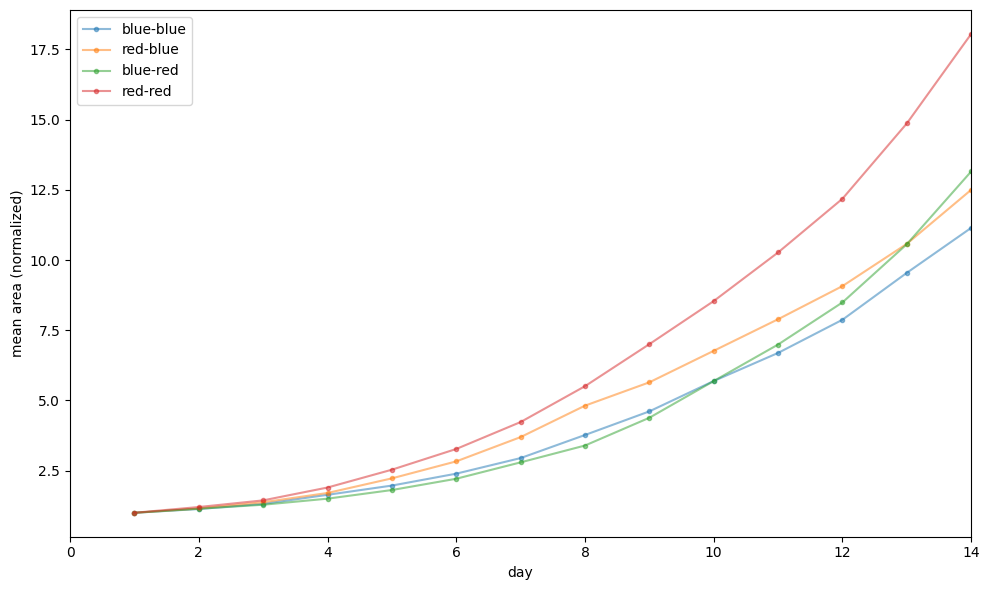

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for recipe, df in recipe_data.items():
    ax.plot(df['day'], df['mean_area'], '.-', alpha=0.5, label=recipe)
ax.set_xlabel('day')
ax.set_ylabel('mean area (normalized)' if normalized_area else 'mean area')
ax.legend()
ax.set_xlim([0, 14])
plt.tight_layout()
plt.show()

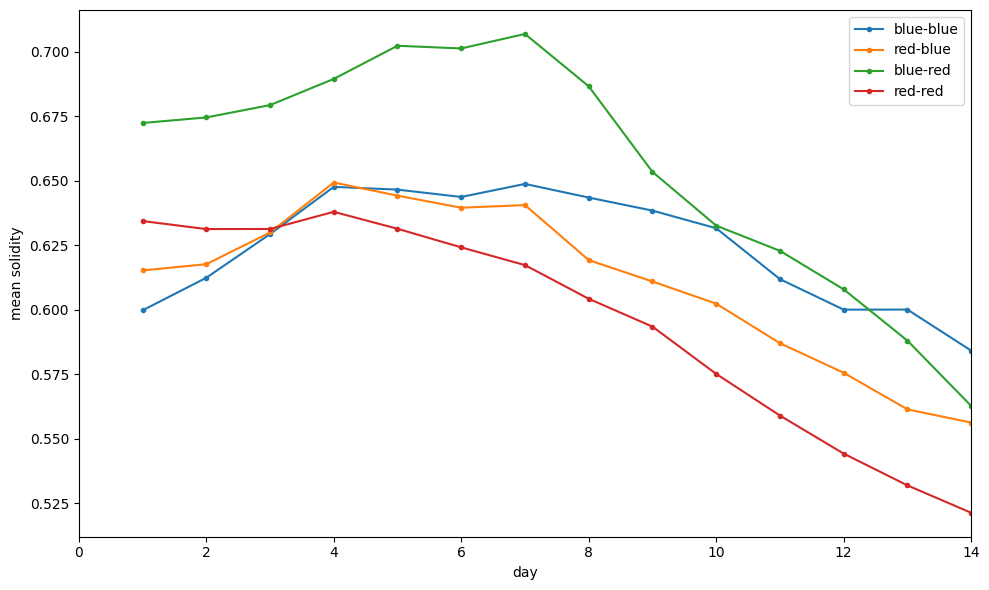

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for recipe, df in recipe_data.items():
    ax.plot(df['day'], df['mean_solidity'], '.-', label=recipe)
ax.set_xlabel('day')
ax.set_ylabel('mean solidity')
ax.legend()
ax.set_xlim([0,14])
#ax.set_ylim([0,20])
plt.tight_layout()
plt.show()